# Latent Dynamics

In [1]:
import numpy as np
from matplotlib.pyplot import subplots
from pathlib import Path
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))
from dynamics import *

## Stable Decay

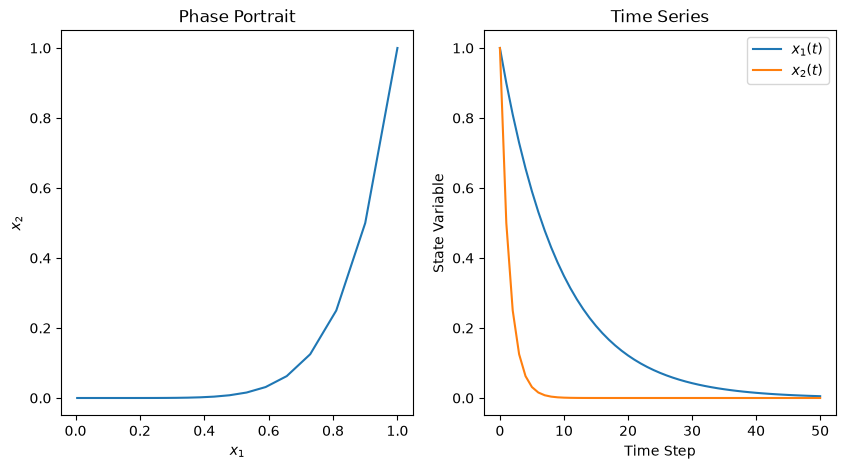

In [2]:
A = np.array([[0.9, 0], [0, 0.5]])
x0 = np.array([1, 1])
T = 50
X = simulate_linear_system(A, x0, T)
x1 = X[:, 0]
x2 = X[:, 1]
t = np.arange(x1.shape[0])

fig, ax = subplots(nrows=1, ncols=2, figsize=(10,5))
ax[0].set_title("Phase Portrait")
ax[0].plot(x1, x2)
ax[0].set_xlabel("$x_1$")
ax[0].set_ylabel("$x_2$")

ax[1].set_title("Time Series")
ax[1].plot(t, x1, label="$x_1(t)$")
ax[1].plot(t, x2, label="$x_2(t)$")
ax[1].set_xlabel("Time Step")
ax[1].set_ylabel("State Variable")
ax[1].legend();

The phase portrait shows the trajectory moving towards the x1-axis before approaching the origin. Hence, the origin is asymptotically stable. This occurs because x2 decays faster than x1, consistent with |lambda1| > |lambda2|. Therefore, the long-term trajectory will become increasingly aligned with v1, although the full state still decays to the origin since |lambda1| < 1.
The time series plot showcases the same behavior. x2(t) decays rapidly towards 0 compared to x1(t). Since each component evolves like lambda^t, the smaller magnitude lambda2 causes faster decay. 

## Unstable Growth

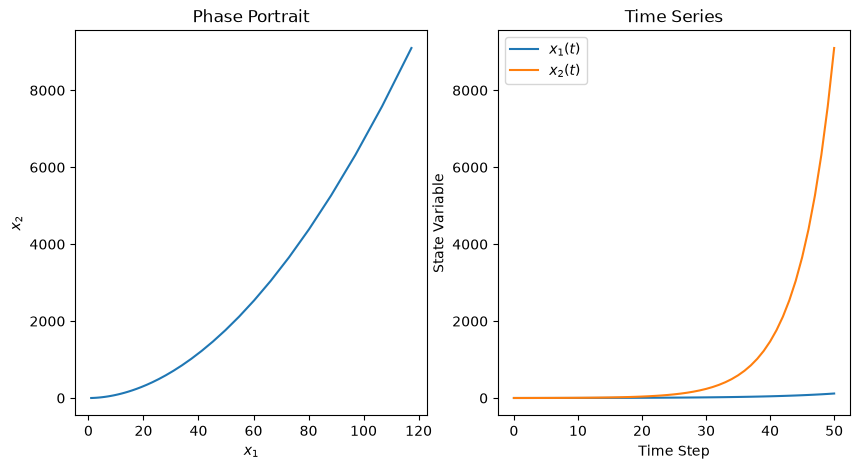

In [3]:
A = np.array([[1.1, 0], [0, 1.2]])
X = simulate_linear_system(A, x0, T)
x1 = X[:, 0]
x2 = X[:, 1]
fig, ax = subplots(nrows=1, ncols=2, figsize=(10,5))
ax[0].set_title("Phase Portrait")
ax[0].plot(x1, x2)
ax[0].set_xlabel("$x_1$")
ax[0].set_ylabel("$x_2$")

ax[1].set_title("Time Series")
ax[1].plot(t, x1, label="$x_1(t)$")
ax[1].plot(t, x2, label="$x_2(t)$")
ax[1].set_xlabel("Time Step")
ax[1].set_ylabel("State Variable")
ax[1].legend();

The following plots display the opposite behavior from the plots in the previous section. Since 1 < |lambda1| < |lambda2|, both modes grow exponentially over time, causing the trajectory to move away from the origin. The time series plot shows x2(t) grow faster than x1(t). This occurs because |lambda1| < |lambda2|. Consequently, the trajectory in the phase portrait becomes increasingly aligned with v2 as the largest eigenvalue in magnitude dominates long-term dynamics.

## Pure Rotation

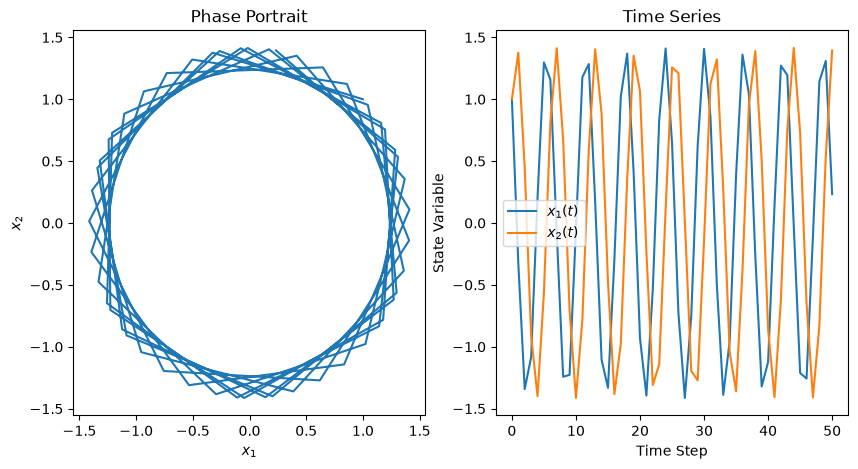

In [4]:
theta = 45
A = rotation_matrix(theta)
X = simulate_linear_system(A, x0, T)
x1 = X[:, 0]
x2 = X[:, 1]
fig, ax = subplots(nrows=1, ncols=2, figsize=(10,5))
ax[0].set_title("Phase Portrait")
ax[0].plot(x1, x2)
ax[0].set_xlabel("$x_1$")
ax[0].set_ylabel("$x_2$")

ax[1].set_title("Time Series")
ax[1].plot(t, x1, label="$x_1(t)$")
ax[1].plot(t, x2, label="$x_2(t)$")
ax[1].set_xlabel("Time Step")
ax[1].set_ylabel("State Variable")
ax[1].legend();

The phase portrait shows that the trajectory neither convergers to nor diverges to the origin. Instead, it remains on a closed orbit indicating that the origin is a center. This is because the eigenvalues of the rotation matrix are complex conjugation both with magnitude 1. Since they both have magnitude 1, the system preserves the norm of the state vectors while continuously rotating it. As a result, the trajectory traces a circle around the origin.
The time series plot shows oscillatory behavior for both x1(t) and x2(t). These oscillations arise from the imaginary components of the eigenvalues, while the unit magnitude prevents both growth and decay.  

## Damped Rotation

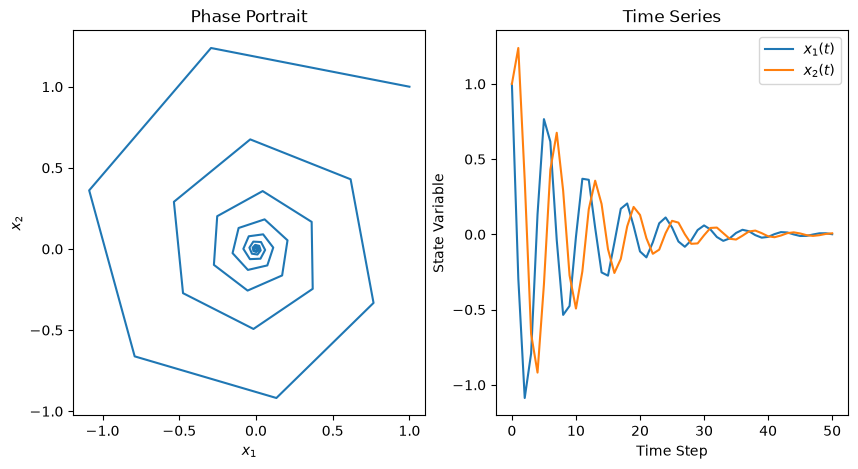

In [5]:
r = 0.9
A = damped_rotation_matrix(theta, r)
X = simulate_linear_system(A, x0, T)
x1 = X[:, 0]
x2 = X[:, 1]
fig, ax = subplots(nrows=1, ncols=2, figsize=(10,5))
ax[0].set_title("Phase Portrait")
ax[0].plot(x1, x2)
ax[0].set_xlabel("$x_1$")
ax[0].set_ylabel("$x_2$")

ax[1].set_title("Time Series")
ax[1].plot(t, x1, label="$x_1(t)$")
ax[1].plot(t, x2, label="$x_2(t)$")
ax[1].set_xlabel("Time Step")
ax[1].set_ylabel("State Variable")
ax[1].legend();

The phase portrait shows that the trajectory spirals inward towards the origin indicating that the origin is a spiral sink. This behavior occurs because the eigenvalues are complex conjugates with magnitude less than 1. The imaginary components produce rotational motion while the magnitude being less than 1 causes the norm of the state vectors to decrease over time. As a result, the trajectory rotates while converging to the origin.
The time series plot shows damping oscillatory motion for both x1(t) and x2(t). The oscillatory behavior results from the complex eigenvalues, while the decreasing sinusoid is a result of |lambda_1,2| < 1. Consequently, the sinusoidal wave approaches zero as t approaches infinity. 